In [1]:
from __future__ import annotations

from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Dict, Any, Tuple, Optional

import numpy as np
import matplotlib.pyplot as plt

from scipy.ndimage import gaussian_filter

from skimage import io, filters, morphology, measure, util
from skimage.filters import frangi
from skimage.morphology import remove_small_objects


In [2]:
from src.biohack.image_detection import load_image
from src.biohack.utils import matrix_to_image

In [14]:
load_image(r"C:\data\UoE\biohack\data\annotated_data\ch20_URA7_URA8_002-crop2_frame_10_mask.tif").shape

(100, 128, 128)

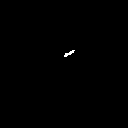

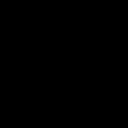

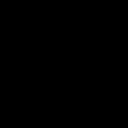

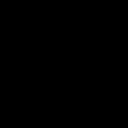

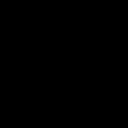

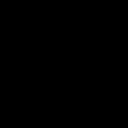

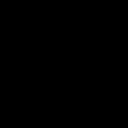

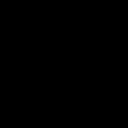

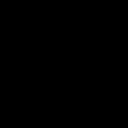

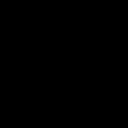

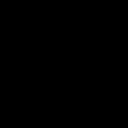

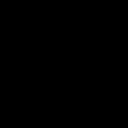

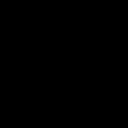

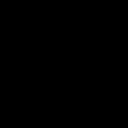

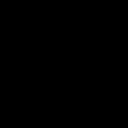

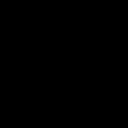

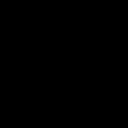

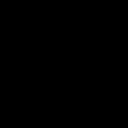

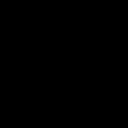

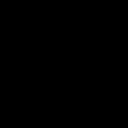

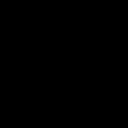

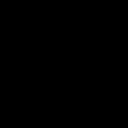

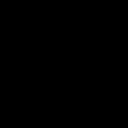

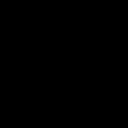

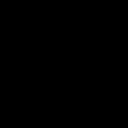

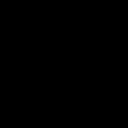

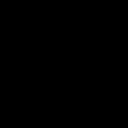

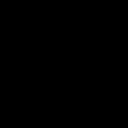

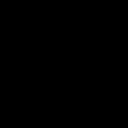

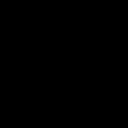

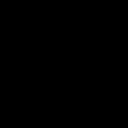

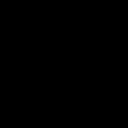

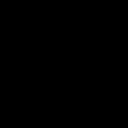

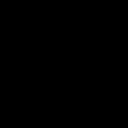

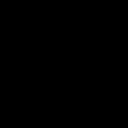

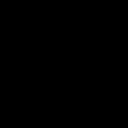

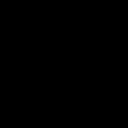

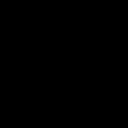

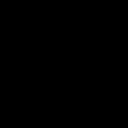

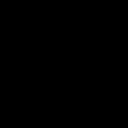

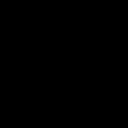

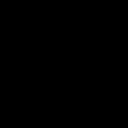

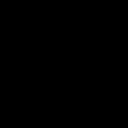

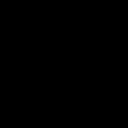

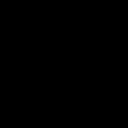

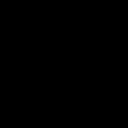

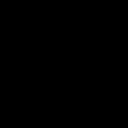

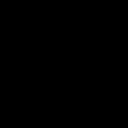

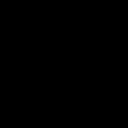

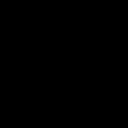

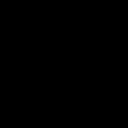

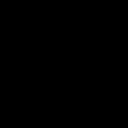

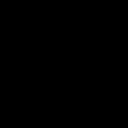

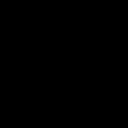

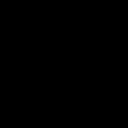

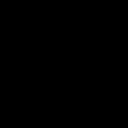

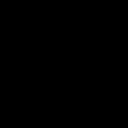

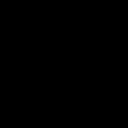

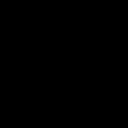

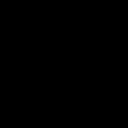

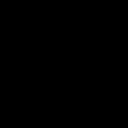

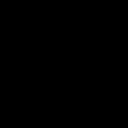

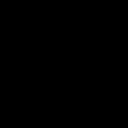

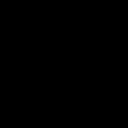

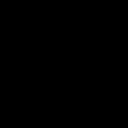

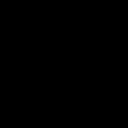

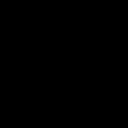

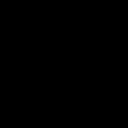

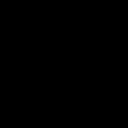

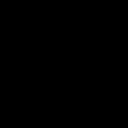

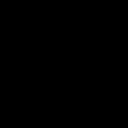

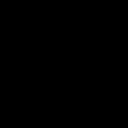

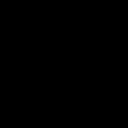

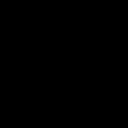

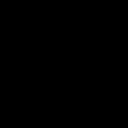

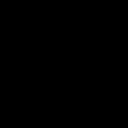

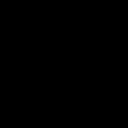

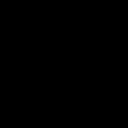

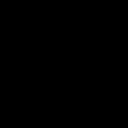

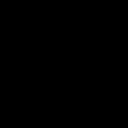

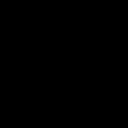

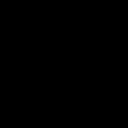

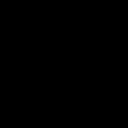

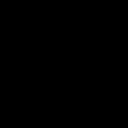

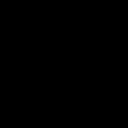

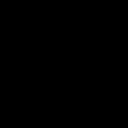

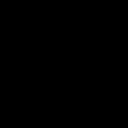

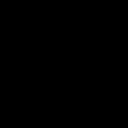

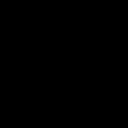

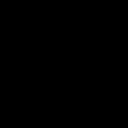

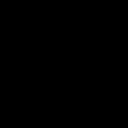

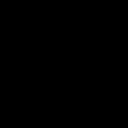

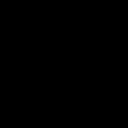

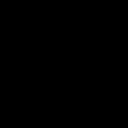

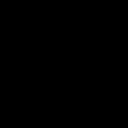

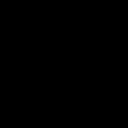

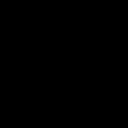

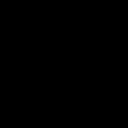

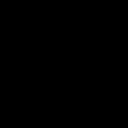

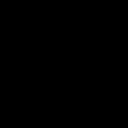

In [16]:
for i in range(100):
    matrix_to_image(load_image(r"C:\data\UoE\biohack\data\annotated_data\ch20_URA7_URA8_002-crop2_frame_10_mask.tif")[i,:,:])

In [8]:


# =========================
# Configuration
# =========================

@dataclass
class FilamentConfig:
    # Normalization
    clip_low_percentile: float = 1.0
    clip_high_percentile: float = 99.0

    # Denoising
    gaussian_sigma: float = 1.0

    # Percentile thresholding
    foreground_percentile: float = 92.0

    # Local thresholding
    local_block_size: int = 35   # must be odd
    local_offset: float = -0.01  # more negative -> more permissive

    # Filament enhancement (Frangi)
    frangi_sigmas: Tuple[float, ...] = (1.0, 2.0, 3.0)
    frangi_threshold_percentile: float = 85.0

    # Cleanup
    min_object_size: int = 20

    # Presence flag
    min_pixels_for_presence: int = 20

    # Plotting
    figure_dpi: int = 140
    cmap: str = "gray"


# =========================
# Utility functions
# =========================

def ensure_grayscale_float(image: np.ndarray) -> np.ndarray:
    """
    Convert image to float grayscale in [0, 1] if needed.
    """
    if image.ndim == 3:
        # If RGB-like, convert using skimage utility
        image = util.img_as_float(image)
        # Simple luminance approximation
        image = image[..., :3].mean(axis=-1)
    else:
        image = util.img_as_float(image)

    return image


def robust_normalize(
    image: np.ndarray,
    low_p: float,
    high_p: float,
) -> np.ndarray:
    """
    Clip to robust percentiles and rescale to [0, 1].
    """
    lo = np.percentile(image, low_p)
    hi = np.percentile(image, high_p)

    if hi <= lo:
        return np.clip(image, 0.0, 1.0)

    clipped = np.clip(image, lo, hi)
    normalized = (clipped - lo) / (hi - lo)
    return np.clip(normalized, 0.0, 1.0)


def denoise_image(image: np.ndarray, sigma: float) -> np.ndarray:
    """
    Light Gaussian smoothing.
    """
    if sigma <= 0:
        return image.copy()
    return gaussian_filter(image, sigma=sigma)


def percentile_threshold_mask(image: np.ndarray, percentile: float) -> np.ndarray:
    """
    Keep pixels >= percentile threshold.
    """
    threshold = np.percentile(image, percentile)
    return image >= threshold


def local_threshold_mask(
    image: np.ndarray,
    block_size: int,
    offset: float,
) -> np.ndarray:
    """
    Adaptive/local thresholding.
    """
    if block_size % 2 == 0:
        raise ValueError("local_block_size must be odd.")

    local_thresh = filters.threshold_local(image, block_size=block_size, offset=offset)
    return image > local_thresh


def enhance_filaments_frangi(
    image: np.ndarray,
    sigmas: Tuple[float, ...],
) -> np.ndarray:
    """
    Frangi filter for line-/ridge-like structures.
    """
    # black_ridges=False because filaments are assumed bright on dark background
    enhanced = frangi(image, sigmas=sigmas, black_ridges=False)
    enhanced = np.nan_to_num(enhanced, nan=0.0, posinf=0.0, neginf=0.0)

    # Normalize enhancement map to [0, 1] for stable thresholding/display
    if enhanced.max() > enhanced.min():
        enhanced = (enhanced - enhanced.min()) / (enhanced.max() - enhanced.min())
    else:
        enhanced = np.zeros_like(enhanced)

    return enhanced


def threshold_enhancement_map(
    enhanced: np.ndarray,
    percentile: float,
) -> np.ndarray:
    """
    Threshold filamentness / enhancement map by percentile.
    """
    threshold = np.percentile(enhanced, percentile)
    return enhanced >= threshold


def combine_masks(
    percentile_mask: np.ndarray,
    local_mask: np.ndarray,
    enhancement_mask: np.ndarray,
) -> np.ndarray:
    """
    Default combination:
        enhancement AND (percentile OR local)
    """
    # return enhancement_mask & (percentile_mask | local_mask)
    return  percentile_mask & enhancement_mask


def cleanup_mask(
    mask: np.ndarray,
    min_object_size: int,
) -> np.ndarray:
    """
    Basic permissive cleanup:
    - remove tiny connected components
    - optional light binary cleanup
    """
    cleaned = remove_small_objects(mask, min_size=min_object_size)

    # Optional tiny cleanup; keep it mild so thin filaments survive
    # cleaned = morphology.binary_opening(cleaned, morphology.disk(1))
    # cleaned = remove_small_objects(cleaned, min_size=min_object_size)

    return cleaned


def derive_filament_present_flag(
    final_mask: np.ndarray,
    min_pixels_for_presence: int,
) -> bool:
    """
    Simple presence rule for first pass.
    """
    return int(final_mask.sum()) >= min_pixels_for_presence


def compute_summary_stats(mask: np.ndarray) -> Dict[str, Any]:
    """
    Simple stats for QC/debug.
    """
    labeled = measure.label(mask)
    props = measure.regionprops(labeled)

    return {
        "foreground_pixels": int(mask.sum()),
        "num_components": len(props),
    }


# =========================
# Main per-image pipeline
# =========================

def process_image(
    image: np.ndarray,
    config: FilamentConfig,
) -> Dict[str, Any]:
    """
    Run the full first-pass filament pipeline on one image.

    Returns a dictionary with:
    - intermediate arrays
    - final binary mask
    - filament_present flag
    - summary stats
    """
    raw = ensure_grayscale_float(image)

    normalized = robust_normalize(
        raw,
        low_p=config.clip_low_percentile,
        high_p=config.clip_high_percentile,
    )

    denoised = denoise_image(normalized, sigma=config.gaussian_sigma)

    pct_mask = percentile_threshold_mask(
        normalized,
        percentile=config.foreground_percentile,
    )

    
    loc_mask = local_threshold_mask(
        denoised,
        block_size=config.local_block_size,
        offset=config.local_offset,
    )

    enhanced = enhance_filaments_frangi(
        denoised,
        sigmas=config.frangi_sigmas,
    )

    enh_mask = threshold_enhancement_map(
        enhanced,
        percentile=config.frangi_threshold_percentile,
    )

    combined_mask = combine_masks(
        percentile_mask=pct_mask,
        local_mask=loc_mask,
        enhancement_mask=enh_mask,
    )

    final_mask = cleanup_mask(
        combined_mask,
        min_object_size=config.min_object_size,
    )

    

    filament_present = derive_filament_present_flag(
        final_mask,
        min_pixels_for_presence=config.min_pixels_for_presence,
    )

    stats = compute_summary_stats(final_mask)
    stats["filament_present"] = filament_present

    return {
        "raw": raw,
        "normalized": normalized,
        "denoised": denoised,
        "percentile_mask": pct_mask,
        "local_mask": loc_mask,
        "enhanced": enhanced,
        "enhancement_mask": enh_mask,
        "combined_mask": combined_mask,
        "final_mask": final_mask,
        "filament_present": filament_present,
        "stats": stats,
        "config": asdict(config),
    }


# =========================
# Plotting / diagnostics
# =========================

def plot_pipeline_results(
    results: Dict[str, Any],
    title: Optional[str] = None,
    save_path: Optional[Path] = None,
    dpi: int = 140,
    cmap: str = "gray",
) -> None:
    """
    Create a multi-panel debug figure showing all major steps.
    """
    raw = results["raw"]
    normalized = results["normalized"]
    denoised = results["denoised"]
    percentile_mask = results["percentile_mask"]
    local_mask = results["local_mask"]
    enhanced = results["enhanced"]
    enhancement_mask = results["enhancement_mask"]
    combined_mask = results["combined_mask"]
    final_mask = results["final_mask"]
    filament_present = results["filament_present"]
    stats = results["stats"]

    fig, axes = plt.subplots(3, 4, figsize=(16, 11), dpi=dpi)
    axes = axes.ravel()

    panels = [
        ("Raw image", raw),
        ("Normalized", normalized),
        ("Denoised", denoised),
        ("Percentile mask", percentile_mask),
        ("Local mask (unused)", local_mask),
        ("Frangi enhanced", enhanced),
        ("Enhancement mask", enhancement_mask),
        ("Combined mask", combined_mask),
        ("Final mask", final_mask),
        ("Overlay: final on raw", raw),
        ("Skeleton (optional preview)", morphology.skeletonize(final_mask)),
        ("Summary", None),
    ]

    for ax, (panel_title, panel_image) in zip(axes, panels):
        ax.set_title(panel_title)
        ax.axis("off")

        if panel_title == "Overlay: final on raw":
            ax.imshow(raw, cmap=cmap)
            masked = np.ma.masked_where(~final_mask, final_mask)
            ax.imshow(masked, alpha=0.8)
        elif panel_title == "Summary":
            summary_text = (
                f"Filament present: {filament_present}\n"
                f"Foreground pixels: {stats['foreground_pixels']}\n"
                f"Connected components: {stats['num_components']}"
            )
            ax.text(
                0.05, 0.95, summary_text,
                va="top", ha="left",
                fontsize=12, family="monospace"
            )
        else:
            ax.imshow(panel_image, cmap=cmap)

    if title is not None:
        fig.suptitle(title, fontsize=14)

    fig.tight_layout()

    if save_path is not None:
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, bbox_inches="tight")

    # plt.show()
    plt.close(fig)


# =========================
# I/O helpers
# =========================

def load_image(image_path: Path) -> np.ndarray:
    """
    Load image from disk.
    """
    return io.imread(str(image_path))


def save_binary_mask(mask: np.ndarray, output_path: Path) -> None:
    """
    Save binary mask as uint8 image (0 or 255).
    """
    output_path.parent.mkdir(parents=True, exist_ok=True)
    io.imsave(str(output_path), (mask.astype(np.uint8) * 255), check_contrast=False)


def process_single_image_file(
    image_path: Path,
    output_dir: Path,
    config: FilamentConfig,
) -> Dict[str, Any]:
    """
    Run the pipeline on one image file and save:
    - final binary mask
    - subplot/debug figure
    """
    image = load_image(image_path)
    results = process_image(image, config=config)

    stem = image_path.stem

    mask_path = output_dir / "masks" / f"{stem}_mask.png"
    fig_path = output_dir / "figures" / f"{stem}_pipeline.png"

    save_binary_mask(results["final_mask"], mask_path)

    plot_pipeline_results(
        results,
        title=stem,
        save_path=fig_path,
        dpi=config.figure_dpi,
        cmap=config.cmap,
    )

    return results


def process_directory(
    input_dir: Path,
    output_dir: Path,
    config: FilamentConfig,
    suffixes: Tuple[str, ...] = (".png", ".jpg", ".jpeg", ".tif", ".tiff"),
) -> Dict[str, Dict[str, Any]]:
    """
    Run the pipeline on all matching images in a directory.
    """
    output_dir.mkdir(parents=True, exist_ok=True)

    image_paths = sorted(
        p for p in input_dir.iterdir()
        if p.is_file() and p.suffix.lower() in suffixes
    )

    all_results: Dict[str, Dict[str, Any]] = {}

    for image_path in image_paths:
        print(f"Processing: {image_path.name}")
        results = process_single_image_file(image_path, output_dir, config)
        all_results[image_path.name] = results

    return all_results

In [9]:

if __name__ == "__main__":
    config = FilamentConfig(
        clip_low_percentile=0.0,
        clip_high_percentile=100.0,
        gaussian_sigma=2.5,
        foreground_percentile=99.5,
        local_block_size=35,
        local_offset=-0.01,
        frangi_sigmas=(1.0, 2.0, 3.0),
        frangi_threshold_percentile=99.5,
        min_object_size=25,
        min_pixels_for_presence=20,
    )

    input_dir = Path("data/separated_frames/")
    output_dir = Path("temp/")

    results = process_directory(
        input_dir=input_dir,
        output_dir=output_dir,
        config=config,
    )

Processing: ch20_URA7_URA8_001-crop2_frame_0.tiff


C:\Users\fabia\AppData\Local\Temp\ipykernel_17812\2775202811.py:159: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  cleaned = remove_small_objects(mask, min_size=min_object_size)


Processing: ch20_URA7_URA8_001-crop2_frame_1.tiff


C:\Users\fabia\AppData\Local\Temp\ipykernel_17812\2775202811.py:159: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  cleaned = remove_small_objects(mask, min_size=min_object_size)


Processing: ch20_URA7_URA8_001-crop2_frame_10.tiff


...

C:\Users\fabia\AppData\Local\Temp\ipykernel_17812\2775202811.py:159: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  cleaned = remove_small_objects(mask, min_size=min_object_size)


Processing: ch20_URA7_URA8_002-crop6_frame_98.tiff


C:\Users\fabia\AppData\Local\Temp\ipykernel_17812\2775202811.py:159: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  cleaned = remove_small_objects(mask, min_size=min_object_size)


Processing: ch20_URA7_URA8_002-crop6_frame_99.tiff


C:\Users\fabia\AppData\Local\Temp\ipykernel_17812\2775202811.py:159: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  cleaned = remove_small_objects(mask, min_size=min_object_size)
